# Quantile band plot

Load multiple PCAPs and visualize

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pcap_tools as pt
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

SAVE_DIR = "../results/plots/"
SAVE_PLOTS = True
CLIENT_IP = "172.17.0.2"
WINDOW_SIZE = 0.01 # seconds
MAX_MATRIX_LEN = 300  # number of windows
PROMPTS = ["weather"]

In [47]:
mtams_in = defaultdict(list)
mtams_out = defaultdict(list)

for prompt in PROMPTS:
    prompt_dir = os.path.join(f"/Users/tarik/data/", f"{prompt}_agent_train/pcap")

    files = [p for p in Path(prompt_dir).iterdir() 
            if p.is_file() and p.suffix.lower() in (".pcap", ".pcapng")]
    
    files = files[:100]  # Limit to first 'x' files for quicker processing

    for p in tqdm(files, desc=f"Processing {prompt_dir}"):
        backend, model, dt = pt.extract_agent_from_filename(p.name)
        backend_code = pt.get_code(backend)

        trace = pt.pcap_to_trace_scapy(str(p), CLIENT_IP)
        mtam = pt.build_mtam(trace, window_size=WINDOW_SIZE, num_windows=MAX_MATRIX_LEN)

        mtams_in[(backend, prompt)].append(mtam[2])
        mtams_out[(backend, prompt)].append(mtam[3])



Processing /Users/tarik/data/weather_agent_train/pcap:  13%|█▎        | 13/100 [00:00<00:01, 62.53it/s]

*** Warning: trace length exceeds num_windows (839 > 300)
*** Warning: trace length exceeds num_windows (734 > 300)
*** Warning: trace length exceeds num_windows (735 > 300)
*** Warning: trace length exceeds num_windows (322 > 300)
*** Warning: trace length exceeds num_windows (804 > 300)


Processing /Users/tarik/data/weather_agent_train/pcap:  20%|██        | 20/100 [00:00<00:01, 57.82it/s]

*** Warning: trace length exceeds num_windows (754 > 300)
*** Warning: trace length exceeds num_windows (340 > 300)
*** Warning: trace length exceeds num_windows (720 > 300)
*** Warning: trace length exceeds num_windows (367 > 300)
*** Warning: trace length exceeds num_windows (332 > 300)
*** Warning: trace length exceeds num_windows (719 > 300)
*** Warning: trace length exceeds num_windows (767 > 300)
*** Warning: trace length exceeds num_windows (739 > 300)
*** Warning: trace length exceeds num_windows (353 > 300)


Processing /Users/tarik/data/weather_agent_train/pcap:  41%|████      | 41/100 [00:00<00:00, 62.59it/s]

...

Processing /Users/tarik/data/weather_agent_train/pcap:  83%|████████▎ | 83/100 [00:01<00:00, 60.76it/s]

*** Warning: trace length exceeds num_windows (311 > 300)
*** Warning: trace length exceeds num_windows (703 > 300)
*** Warning: trace length exceeds num_windows (690 > 300)
*** Warning: trace length exceeds num_windows (1351 > 300)
*** Warning: trace length exceeds num_windows (789 > 300)
*** Warning: trace length exceeds num_windows (739 > 300)
*** Warning: trace length exceeds num_windows (373 > 300)
*** Warning: trace length exceeds num_windows (361 > 300)


Processing /Users/tarik/data/weather_agent_train/pcap:  97%|█████████▋| 97/100 [00:01<00:00, 62.99it/s]

*** Warning: trace length exceeds num_windows (313 > 300)
*** Warning: trace length exceeds num_windows (797 > 300)
*** Warning: trace length exceeds num_windows (755 > 300)
*** Warning: trace length exceeds num_windows (335 > 300)
*** Warning: trace length exceeds num_windows (406 > 300)
*** Warning: trace length exceeds num_windows (314 > 300)
*** Warning: trace length exceeds num_windows (310 > 300)
*** Warning: trace length exceeds num_windows (399 > 300)


Processing /Users/tarik/data/weather_agent_train/pcap: 100%|██████████| 100/100 [00:01<00:00, 61.55it/s]


In [67]:
PALETTE = sns.color_palette("tab10")

def band_plot(data_in, data_out, model= None):
    # We have MAX_MATRIX_LEN and TIME_WINDOW_SIZE defined globally
    # Their product gives us the time axis
    t = np.arange(data_in.shape[1]) * WINDOW_SIZE
    
    sns.set_theme(style="whitegrid")

    fig = plt.figure(figsize=(6, 4))
    fig.tight_layout()

    #############
    # Incoming #
    q10, q25, q50, q75, q90 = np.percentile(
        data_in, [10, 25, 50, 75, 90], axis=0
    )

    # percentile bands, median line
    plt.fill_between(t, q10, q90, alpha=0.15, color=PALETTE[0], label="In 10–90%")
    plt.fill_between(t, q25, q75, alpha=0.3, color=PALETTE[0], label="In 25–75%")
    plt.plot(t, q50, color=PALETTE[0], linewidth=2, label="In median")

    #############
    # Outgoing #
    q10, q25, q50, q75, q90 = -np.percentile(
        data_out, [10, 25, 50, 75, 90], axis=0
    )

    # percentile bands, median line
    plt.fill_between(t, q10, q90, alpha=0.15, color=PALETTE[1], label="Out 10–90%")
    plt.fill_between(t, q25, q75, alpha=0.3, color=PALETTE[1], label="Out 25–75%")
    plt.plot(t, q50, color=PALETTE[1], linewidth=2, label="Out median")

    plt.xlabel("Time (s)")
    plt.ylabel("Data volume (bytes)")
    if model:
        plt.title(f"Traffic pattern, {model}")
    plt.legend()
    plt.tight_layout()
    if SAVE_PLOTS and model:    
        plt.savefig(os.path.join(SAVE_DIR, f"band_plot_{model}.png"), dpi=300)
    plt.show()

Plotting backend: openai, prompt: weather, data shape: (36, 300)


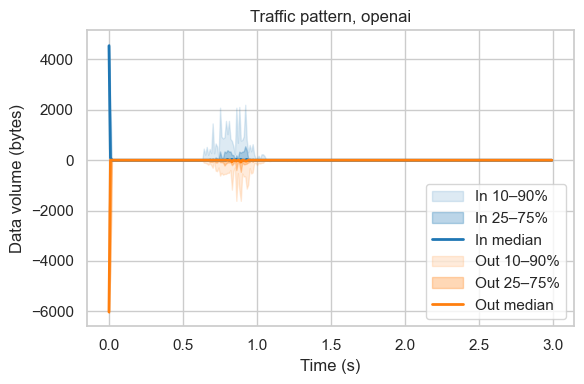

Plotting backend: gemini, prompt: weather, data shape: (33, 300)


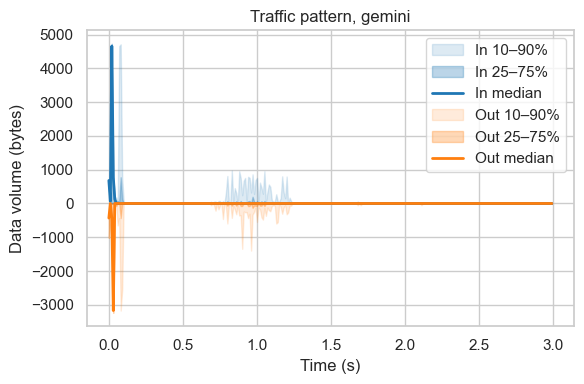

Plotting backend: deepseek, prompt: weather, data shape: (31, 300)


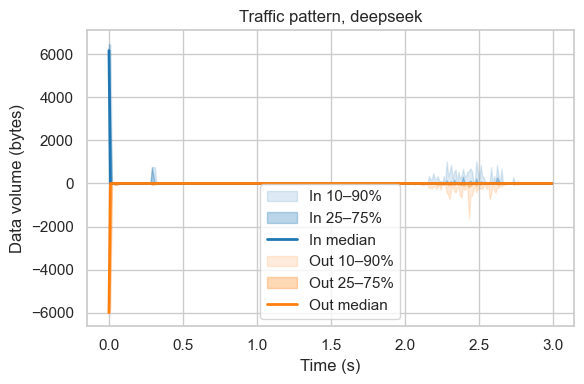

In [68]:

for prompt in PROMPTS:
    for backend in pt.BACKEND_CODES:
        # data shape: (n_series, n_time)
        data_in = np.array(mtams_in[(backend, prompt)])
        data_out = np.array(mtams_out[(backend, prompt)])
        if data_in is not None and data_in.size > 0:
            print(f"Plotting backend: {backend}, prompt: {prompt}, data shape: {data_in.shape}")
            band_plot(data_in, data_out, backend)
# data shape: (n_series, n_time)
#data = np.array(mtams_in[('openai', 'weather')])  # Example for backend_code 0
#band_plot(data, color="tab:blue")